<a href="https://colab.research.google.com/github/iarabertopena/ml-learning-lab/blob/main/10_fold_cross_validation-ml_learning_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Bibliotecas

In [ ]:
%%writefile requirements.txt
numpy
pandas
scipy
scikit-learn

matplotlib
seaborn
scikit-plot
autorank
tqdm
scikit-multilearn-ng

Writing requirements.txt


In [ ]:
!pip install -r requirements.txt

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.6/109.6 kB 4.7 MB/s eta 0:00:00
  Created wheel for baycomp: filename=baycomp-1.0.3-py3-none-any.whl size=18027 sha256=fd90655ba165045b6b32bd9aa5f8613d0ee818eb438032ccac442af2703b0886
  Stored in directory: /root/.cache/pip/wheels/ff/39/6a/f87e05ad75b9d87f4eb262a897ec2fe3aab09449d13e3c3b2c
  Created wheel for liac-arff: filename=liac_arff-2.5.0-py3-none-any.whl size=11717 sha256=721457db7fa05fa44a9079b2c3fafc6f1d01a7b872066780d92c779c9331d56d
  Stored in directory: /root/.cache/pip/wheels/a9/ac/cf/c2919807a5c623926d217c0a18eb5b457e5c19d242c3b5963a
Successfully built baycomp liac-arff


### Imports

In [ ]:
import numpy as np
import pandas as pd

from sklearn import metrics
from sklearn.model_selection import StratifiedKFold
from skmultilearn.model_selection import IterativeStratification
from sklearn.model_selection import KFold
from sklearn.metrics import hamming_loss, f1_score, roc_auc_score, average_precision_score
from sklearn.ensemble import RandomForestClassifier
from skmultilearn.problem_transform import BinaryRelevance, LabelPowerset
from skmultilearn.ensemble import RakelD
from skmultilearn.adapt import MLkNN

from tqdm import tqdm

### Datasets

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import tarfile

path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos/emotions.tar.gz"

with tarfile.open(path, "r:gz") as tar:
    tar.extractall("/content/emotions")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_1347/3433904962.py:9: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("/content/emotions")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import tarfile

path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos/VirusGO.tar.gz"

with tarfile.open(path, "r:gz") as tar:
    tar.extractall("/content/VirusGO")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_1347/290855057.py:9: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("/content/VirusGO")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import tarfile

path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos/VirusPseAAC.tar.gz"

with tarfile.open(path, "r:gz") as tar:
    tar.extractall("/content/VirusPseAAC")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_1347/3928386207.py:9: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("/content/VirusPseAAC")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import tarfile

path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos/GpositiveGO.tar.gz"

with tarfile.open(path, "r:gz") as tar:
    tar.extractall("/content/GpositiveGO")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_1347/2743622664.py:9: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("/content/GpositiveGO")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import tarfile

path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos/GpositivePseAAC.tar.gz"

with tarfile.open(path, "r:gz") as tar:
    tar.extractall("/content/GpositivePseAAC")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_1347/2522697500.py:9: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("/content/GpositivePseAAC")


In [ ]:
datasets_paths = {
    "emotions": "/content/emotions/emotions/CrossValidation",
    "VirusGO": "/content/VirusGO/VirusGO/CrossValidation",
    "VirusPseAAC": "/content/VirusPseAAC/VirusPseAAC/CrossValidation",
    "GpositiveGO": "/content/GpositiveGO/GpositiveGO/CrossValidation",
    "GpositivePseAAC": "/content/GpositivePseAAC/GpositivePseAAC/CrossValidation"
}

n_labels_dict = {
    "emotions": 6,
    "VirusGO": 6,
    "VirusPseAAC": 6,
    "GpositiveGO": 4,
    "GpositivePseAAC": 4
}

### Métricas de avaliação

In [ ]:
def evaluate_metrics(y_true, y_pred, y_prob):

    results = {}

    # binarizar (threshold 0.5)
    y_pred_bin = (y_prob >= 0.5).astype(int)

    results["hamming"] = hamming_loss(y_true, y_pred_bin)

    results["f1_micro"] = f1_score(y_true, y_pred_bin, average='micro')
    results["f1_macro"] = f1_score(y_true, y_pred_bin, average='macro')

    try:
      results["auprc_micro"] = average_precision_score(y_true, y_prob, average='micro')
      results["auprc_macro"] = average_precision_score(y_true, y_prob, average='macro')
    except:
      results["auprc_micro"] = np.nan
      results["auprc_macro"] = np.nan

    try:
      results["auc_micro"] = roc_auc_score(y_true, y_prob, average='micro')
      results["auc_macro"] = roc_auc_score(y_true, y_prob, average='macro')
    except:
      results["auc_micro"] = np.nan
      results["auc_macro"] = np.nan

    return results

In [ ]:
# Hamming Loss:
# Proporção de labels incorretamente previstas (falsos positivos + falsos negativos).
# Quanto menor, melhor.

# F1-score (micro):
# Agrega contribuições de todas as classes.
# Favorece classes mais frequentes.

# F1-score (macro):
# Calcula F1 por classe e tira média.
# Dá o mesmo peso para classes raras e frequentes.


# AUPRC (Área sob a curva Precision-Recall):
# Mais informativa que AUC quando há desbalanceamento.
# Mede qualidade das probabilidades previstas.
    # Micro: avalia globalmente (classes frequentes têm mais peso)
    # Macro: média entre classes (importante para labels raros)

# AUC:
# Mede a capacidade do modelo de separar classes positivas e negativas.
    # Micro: mais influenciado por classes frequentes
    # Macro: trata todas as classes igualmente

### Algoritmos

#### Definindo os modelos:

In [ ]:
# Definindo os modelos:
def get_models():
    return {
        "BR": BinaryRelevance(
            classifier=RandomForestClassifier(n_estimators=100, random_state=42)
        ),

        "LP": LabelPowerset(
            classifier=RandomForestClassifier(n_estimators=100, random_state=42)
        ),

        "RAkEL": RakelD(
            base_classifier=RandomForestClassifier(n_estimators=100, random_state=42),
            labelset_size=2
        ),

        "RF": RandomForestClassifier(n_estimators=100, random_state=42),

        "MLkNN": MLkNN(k=10)
    }

In [ ]:
# BR (Binary Relevance):
# Decompõe o problema multi-label em vários classificadores binários independentes.
# Simples e eficiente, mas ignora correlação entre labels.

# LP (Label Powerset):
# Transforma o problema multi-label em multi-classe usando combinações de labels.
# Captura dependências, mas pode gerar muitas classes distintas.

# RAkEL:
# Usa vários modelos LP em subconjuntos aleatórios de labels.
# Reduz a complexidade do LP e mantém parte das dependências.

# MLkNN:
# Extensão do kNN para multi-label baseada em probabilidade.
# Considera vizinhos mais próximos e estima a probabilidade de cada label.
# Consegue capturar dependência local entre labels.

# Random Forest (adaptado para multi-label):
# Conjunto de árvores de decisão usado como classificador base.
# Robusto a ruído e capaz de modelar relações não lineares.
# Quando usado com BR ou LP, herda suas características.

#### Loop principal + cross validation

In [ ]:
def run_experiment_folds(models, base_path, n_labels):

    import os
    import pandas as pd
    import numpy as np
    import copy

    path_tr = os.path.join(base_path, "Tr")
    path_vl = os.path.join(base_path, "Vl")
    path_ts = os.path.join(base_path, "Ts")

    def sort_key(filename):
        return int(filename.split("-")[-1].split(".")[0])

    arquivos_tr = sorted([f for f in os.listdir(path_tr) if f.endswith(".arff")], key=sort_key)
    arquivos_vl = sorted([f for f in os.listdir(path_vl) if f.endswith(".arff")], key=sort_key)
    arquivos_ts = sorted([f for f in os.listdir(path_ts) if f.endswith(".arff")], key=sort_key)

    results = {name: [] for name in models.keys()}

    for tr_file, vl_file, ts_file in zip(arquivos_tr, arquivos_vl, arquivos_ts):

        print("Rodando fold:", tr_file)

        # carregar
        tr = load_data(os.path.join(path_tr, tr_file))
        vl = load_data(os.path.join(path_vl, vl_file))
        ts = load_data(os.path.join(path_ts, ts_file))

        # concatenação
        train_full = pd.concat([tr, vl], axis=0)

        # separar X e Y (ajustar n_labels!)
        X_train = train_full.iloc[:, :-n_labels]
        Y_train = train_full.iloc[:, -n_labels:]

        X_test = ts.iloc[:, :-n_labels]
        Y_test = ts.iloc[:, -n_labels:]

        # rodar modelos
        for name in models:
            model = copy.deepcopy(models[name])

            model.fit(X_train.values, Y_train.values)
            Y_pred = model.predict(X_test.values)

            y_prob = None
            if hasattr(model, "predict_proba"):
              try:
                y_prob = model.predict_proba(X_test.values)

                if isinstance(y_prob, list):
                  y_prob = np.array([p[:, 1] for p in y_prob]).T

              except:
                y_prob = None

            #res = evaluate_metrics(Y_test.values, Y_pred, None)
            res = evaluate_metrics(Y_test.values, Y_pred, y_prob)
            results[name].append(res)

    return results

In [ ]:
from scipy.io import arff
import pandas as pd

def load_data(path):
    if path.endswith(".arff"):
        data, meta = arff.loadarff(path)
        df = pd.DataFrame(data)

        # converter de bytes para string
        for col in df.select_dtypes([object]).columns:
            df[col] = df[col].str.decode("utf-8")

        # converter tudo para numérico
        df = df.apply(pd.to_numeric)

        return df

    elif path.endswith(".csv"):
        return pd.read_csv(path)

    else:
        raise ValueError(f"Formato não suportado: {path}")

In [ ]:
results = run_experiment_folds(get_models(), base_path, n_labels)

Rodando fold: VirusPseAAC-Split-Tr-1.arff


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/di

Rodando fold: VirusPseAAC-Split-Tr-2.arff
Rodando fold: VirusPseAAC-Split-Tr-3.arff


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/di

Rodando fold: VirusPseAAC-Split-Tr-4.arff
Rodando fold: VirusPseAAC-Split-Tr-5.arff
Rodando fold: VirusPseAAC-Split-Tr-6.arff
Rodando fold: VirusPseAAC-Split-Tr-7.arff
Rodando fold: VirusPseAAC-Split-Tr-8.arff
Rodando fold: VirusPseAAC-Split-Tr-9.arff
Rodando fold: VirusPseAAC-Split-Tr-10.arff


#### Resumindo os resultados:

In [ ]:
# Resumindo os resultados:
def summarize_results(results):
    summary = {}

    for model, res_list in results.items():

        # pula modelos vazios (por conta do MKnn)
        if len(res_list) == 0:
            print(f"{model} sem resultados, ignorando... :/")
            continue

        summary[model] = {}

        for metric in res_list[0].keys():
            values = [
                r[metric]
                for r in res_list
                if r[metric] is not None and not np.isnan(r[metric])
            ]

            if len(values) > 0:
                summary[model][metric] = (
                    np.mean(values),
                    np.std(values)
                )
            else:
                summary[model][metric] = (np.nan, np.nan)

    return summary

In [ ]:
summary = summarize_results(results)

for model, metrics in summary.items():
    print(f"\n--- {model} ---")
    for k, (mean, std) in metrics.items():
        if np.isnan(mean):
            print(f"{k}: nan")
        else:
            print(f"{k}: {mean:.4f} ± {std:.4f}")


--- BR ---
hamming: 0.1731 ± 0.0163
f1_micro: 0.4280 ± 0.0569
f1_macro: 0.2849 ± 0.0663
auprc_micro: nan
auprc_macro: nan
auc_micro: nan
auc_macro: nan

--- LP ---
hamming: 0.1730 ± 0.0213
f1_micro: 0.3899 ± 0.0748
f1_macro: 0.2838 ± 0.0728
auprc_micro: nan
auprc_macro: nan
auc_micro: nan
auc_macro: nan

--- RAkEL ---
hamming: 0.1812 ± 0.0171
f1_micro: 0.3851 ± 0.0654
f1_macro: 0.2607 ± 0.0643
auprc_micro: nan
auprc_macro: nan
auc_micro: nan
auc_macro: nan

--- RF ---
hamming: 0.1796 ± 0.0220
f1_micro: 0.3532 ± 0.0993
f1_macro: 0.2537 ± 0.0791
auprc_micro: 0.5854 ± 0.0498
auprc_macro: 0.5440 ± 0.0401
auc_micro: 0.8398 ± 0.0211
auc_macro: 0.7450 ± 0.0555

--- MLkNN ---
hamming: 0.1911 ± 0.0317
f1_micro: 0.4698 ± 0.0775
f1_macro: 0.3474 ± 0.0920
auprc_micro: nan
auprc_macro: nan
auc_micro: nan
auc_macro: nan


### Rodando os 5 datasets:

In [ ]:
all_results = {}

for name, base_path in datasets_paths.items():
    print(f"\n====================")
    print(f"Dataset: {name}")
    print(f"====================")

    n_labels = n_labels_dict[name]

    results = run_experiment_folds(get_models(), base_path, n_labels)

    summary = summarize_results(results)

    all_results[name] = summary


Dataset: emotions
Rodando fold: emotions-Split-Tr-1.arff
Rodando fold: emotions-Split-Tr-2.arff
Rodando fold: emotions-Split-Tr-3.arff
Rodando fold: emotions-Split-Tr-4.arff
Rodando fold: emotions-Split-Tr-5.arff
Rodando fold: emotions-Split-Tr-6.arff
Rodando fold: emotions-Split-Tr-7.arff
Rodando fold: emotions-Split-Tr-8.arff
Rodando fold: emotions-Split-Tr-9.arff
Rodando fold: emotions-Split-Tr-10.arff

Dataset: VirusGO
Rodando fold: VirusGO-Split-Tr-1.arff


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


Rodando fold: VirusGO-Split-Tr-2.arff
Rodando fold: VirusGO-Split-Tr-3.arff


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/di

Rodando fold: VirusGO-Split-Tr-4.arff
Rodando fold: VirusGO-Split-Tr-5.arff
Rodando fold: VirusGO-Split-Tr-6.arff
Rodando fold: VirusGO-Split-Tr-7.arff
Rodando fold: VirusGO-Split-Tr-8.arff
Rodando fold: VirusGO-Split-Tr-9.arff
Rodando fold: VirusGO-Split-Tr-10.arff

Dataset: VirusPseAAC
Rodando fold: VirusPseAAC-Split-Tr-1.arff


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/di

Rodando fold: VirusPseAAC-Split-Tr-2.arff
Rodando fold: VirusPseAAC-Split-Tr-3.arff


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/di

Rodando fold: VirusPseAAC-Split-Tr-4.arff
Rodando fold: VirusPseAAC-Split-Tr-5.arff
Rodando fold: VirusPseAAC-Split-Tr-6.arff
Rodando fold: VirusPseAAC-Split-Tr-7.arff
Rodando fold: VirusPseAAC-Split-Tr-8.arff
Rodando fold: VirusPseAAC-Split-Tr-9.arff
Rodando fold: VirusPseAAC-Split-Tr-10.arff

Dataset: GpositiveGO
Rodando fold: GpositiveGO-Split-Tr-1.arff
Rodando fold: GpositiveGO-Split-Tr-2.arff
Rodando fold: GpositiveGO-Split-Tr-3.arff
Rodando fold: GpositiveGO-Split-Tr-4.arff
Rodando fold: GpositiveGO-Split-Tr-5.arff
Rodando fold: GpositiveGO-Split-Tr-6.arff
Rodando fold: GpositiveGO-Split-Tr-7.arff
Rodando fold: GpositiveGO-Split-Tr-8.arff
Rodando fold: GpositiveGO-Split-Tr-9.arff
Rodando fold: GpositiveGO-Split-Tr-10.arff

Dataset: GpositivePseAAC
Rodando fold: GpositivePseAAC-Split-Tr-1.arff
Rodando fold: GpositivePseAAC-Split-Tr-2.arff
Rodando fold: GpositivePseAAC-Split-Tr-3.arff
Rodando fold: GpositivePseAAC-Split-Tr-4.arff
Rodando fold: GpositivePseAAC-Split-Tr-5.arff
Rodand

In [ ]:
for dataset, summary in all_results.items():
    print(f"\n====================")
    print(f"Dataset: {dataset}")
    print(f"====================")

    for model, metrics in summary.items():
        print(f"\n--- {model} ---")
        for metric, (mean, std) in metrics.items():
            if np.isnan(mean):
                print(f"{metric}: nan")
            else:
                print(f"{metric}: {mean:.4f} ± {std:.4f}")


Dataset: emotions

--- BR ---
hamming: 0.1800 ± 0.0164
f1_micro: 0.6869 ± 0.0256
f1_macro: 0.6571 ± 0.0300
auprc_micro: nan
auprc_macro: nan
auc_micro: nan
auc_macro: nan

--- LP ---
hamming: 0.1854 ± 0.0167
f1_micro: 0.6688 ± 0.0322
f1_macro: 0.6288 ± 0.0292
auprc_micro: nan
auprc_macro: nan
auc_micro: nan
auc_macro: nan

--- RAkEL ---
hamming: 0.1825 ± 0.0185
f1_micro: 0.6759 ± 0.0395
f1_macro: 0.6433 ± 0.0364
auprc_micro: nan
auprc_macro: nan
auc_micro: nan
auc_macro: nan

--- RF ---
hamming: 0.1840 ± 0.0209
f1_micro: 0.6766 ± 0.0355
f1_macro: 0.6410 ± 0.0376
auprc_micro: 0.7562 ± 0.0367
auprc_macro: 0.7528 ± 0.0367
auc_micro: 0.8748 ± 0.0199
auc_macro: 0.8590 ± 0.0211

--- MLkNN ---
hamming: 0.2582 ± 0.0154
f1_micro: 0.5149 ± 0.0363
f1_macro: 0.4551 ± 0.0384
auprc_micro: nan
auprc_macro: nan
auc_micro: nan
auc_macro: nan

Dataset: VirusGO

--- BR ---
hamming: 0.0533 ± 0.0263
f1_micro: 0.8641 ± 0.0656
f1_macro: 0.8160 ± 0.0970
auprc_micro: nan
auprc_macro: nan
auc_micro: nan
auc_ma

### Tabelas de resultados:

In [ ]:
import pandas as pd

rows = []

for dataset_name, models in all_results.items():
    row = {"dataset": dataset_name}

    for model_name, metrics in models.items():
        mean, std = metrics["hamming"]
        row[model_name] = mean

    rows.append(row)

df = pd.DataFrame(rows)
df = df.set_index("dataset")

print("Tabela de resultados: hamming loss")
print(df)

best_hamming = df_results.idxmin(axis=1)  # porque hamming é menor melhor
print("\nMelhor modelo por dataset:")
print(best_hamming)

Tabela de resultados: hamming loss
                       BR        LP     RAkEL        RF     MLkNN
dataset                                                          
emotions         0.179966  0.185392  0.182539  0.183976  0.258201
VirusGO          0.053333  0.054960  0.055000  0.054921  0.079048
VirusPseAAC      0.173095  0.173016  0.177103  0.179603  0.191111
GpositiveGO      0.031336  0.029894  0.031364  0.030855  0.030311
GpositivePseAAC  0.144562  0.149379  0.156628  0.148454  0.144986

Melhor modelo por dataset:
dataset
emotions           BR
VirusGO            BR
VirusPseAAC        LP
GpositiveGO        LP
GpositivePseAAC    BR
dtype: object


In [ ]:
import pandas as pd

rows = []

for dataset_name, models in all_results.items():
    row = {"dataset": dataset_name}

    for model_name, metrics in models.items():
        mean, std = metrics["f1_micro"]
        row[model_name] = mean

    rows.append(row)

df = pd.DataFrame(rows)
df = df.set_index("dataset")

print("Tabela de resultados: f1_micro")
print(df)

best_f1_micro = df.idxmax(axis=1)
print("\nMelhor modelo por dataset:")
print(best_f1_micro)

Tabela de resultados: f1_micro
                       BR        LP     RAkEL        RF     MLkNN
dataset                                                          
emotions         0.686909  0.668780  0.675938  0.676610  0.514890
VirusGO          0.864111  0.858351  0.859309  0.858521  0.797980
VirusPseAAC      0.427957  0.389879  0.387690  0.353153  0.469776
GpositiveGO      0.937221  0.939607  0.936698  0.937839  0.938295
GpositivePseAAC  0.642621  0.628353  0.606319  0.629896  0.679966

Melhor modelo por dataset:
dataset
emotions              BR
VirusGO               BR
VirusPseAAC        MLkNN
GpositiveGO           LP
GpositivePseAAC    MLkNN
dtype: object


In [ ]:
import pandas as pd

rows = []

for dataset_name, models in all_results.items():
    row = {"dataset": dataset_name}

    for model_name, metrics in models.items():
        mean, std = metrics["f1_macro"]
        row[model_name] = mean

    rows.append(row)

df = pd.DataFrame(rows)
df = df.set_index("dataset")

print("Tabela de resultados: f1_macro")
print(df)

best_f1_macro = df.idxmax(axis=1)
print("\nMelhor modelo por dataset:")
print(best_f1_macro)

Tabela de resultados: f1_macro
                       BR        LP     RAkEL        RF     MLkNN
dataset                                                          
emotions         0.657074  0.628754  0.643291  0.640969  0.455138
VirusGO          0.816045  0.813881  0.810084  0.803228  0.620898
VirusPseAAC      0.284883  0.283778  0.265989  0.253692  0.347422
GpositiveGO      0.788462  0.791231  0.788933  0.789468  0.840346
GpositivePseAAC  0.444562  0.426170  0.402967  0.428936  0.540844

Melhor modelo por dataset:
dataset
emotions              BR
VirusGO               BR
VirusPseAAC        MLkNN
GpositiveGO        MLkNN
GpositivePseAAC    MLkNN
dtype: object


In [ ]:
import pandas as pd

rows = []

for dataset_name, models in all_results.items():
    row = {"dataset": dataset_name}

    for model_name, metrics in models.items():
        mean, std = metrics["auprc_micro"]
        row[model_name] = mean

    rows.append(row)

df = pd.DataFrame(rows)
df = df.set_index("dataset")

print("Tabela de resultados: auprc_micro")
print(df)

best_auprc_micro = df.idxmax(axis=1)
print("\nMelhor modelo por dataset:")
print(best_auprc_micro)

Tabela de resultados: auprc_micro
                 BR  LP  RAkEL        RF  MLkNN
dataset                                        
emotions        NaN NaN    NaN  0.756235    NaN
VirusGO         NaN NaN    NaN  0.929681    NaN
VirusPseAAC     NaN NaN    NaN  0.585426    NaN
GpositiveGO     NaN NaN    NaN  0.983618    NaN
GpositivePseAAC NaN NaN    NaN  0.780585    NaN

Melhor modelo por dataset:
dataset
emotions           RF
VirusGO            RF
VirusPseAAC        RF
GpositiveGO        RF
GpositivePseAAC    RF
dtype: object


In [ ]:
import pandas as pd

rows = []

for dataset_name, models in all_results.items():
    row = {"dataset": dataset_name}

    for model_name, metrics in models.items():
        mean, std = metrics["auprc_macro"]
        row[model_name] = mean

    rows.append(row)

df = pd.DataFrame(rows)
df = df.set_index("dataset")

print("Tabela de resultados: auprc_macro")
print(df)

best_auprc_macro = df.idxmax(axis=1)
print("\nMelhor modelo por dataset:")
print(best_auprc_macro)

Tabela de resultados: auprc_macro
                 BR  LP  RAkEL        RF  MLkNN
dataset                                        
emotions        NaN NaN    NaN  0.752843    NaN
VirusGO         NaN NaN    NaN  0.909107    NaN
VirusPseAAC     NaN NaN    NaN  0.544009    NaN
GpositiveGO     NaN NaN    NaN  0.930762    NaN
GpositivePseAAC NaN NaN    NaN  0.651172    NaN

Melhor modelo por dataset:
dataset
emotions           RF
VirusGO            RF
VirusPseAAC        RF
GpositiveGO        RF
GpositivePseAAC    RF
dtype: object


In [ ]:
import pandas as pd

rows = []

for dataset_name, models in all_results.items():
    row = {"dataset": dataset_name}

    for model_name, metrics in models.items():
        mean, std = metrics["auc_micro"]
        row[model_name] = mean

    rows.append(row)

df = pd.DataFrame(rows)
df = df.set_index("dataset")

print("Tabela de resultados: auc_micro")
print(df)

best_auc_micro = df.idxmax(axis=1)
print("\nMelhor modelo por dataset:")
print(best_auc_micro)

Tabela de resultados: auc_micro
                     BR        LP     RAkEL        RF     MLkNN
dataset                                                        
Gram_positive  0.992741  0.992251  0.991942  0.991885  0.985998
CHD_49         0.785763  0.791198  0.788706  0.794110  0.760858
VirusGO        0.979013  0.979290  0.981577  0.979385  0.958579
emotions       0.872437  0.874611  0.872242  0.875396  0.763365
VirusPseAAC    0.768864  0.777716  0.776805  0.789049  0.767955

Melhor modelo por dataset:
dataset
Gram_positive       BR
CHD_49              RF
VirusGO          RAkEL
emotions            RF
VirusPseAAC         RF
dtype: object


In [ ]:
import pandas as pd

rows = []

for dataset_name, models in all_results.items():
    row = {"dataset": dataset_name}

    for model_name, metrics in models.items():
        mean, std = metrics["auc_macro"]
        row[model_name] = mean

    rows.append(row)

df = pd.DataFrame(rows)
df = df.set_index("dataset")

print("Tabela de resultados: auc_macro")
print(df)

best_auc_macro = df.idxmax(axis=1)
print("\nMelhor modelo por dataset:")
print(best_auc_macro)

Tabela de resultados: auc_macro
                     BR        LP     RAkEL        RF     MLkNN
dataset                                                        
Gram_positive  0.989504  0.989061  0.988732  0.988538  0.976438
CHD_49         0.568273  0.589233  0.575007  0.585367  0.539308
VirusGO        0.976501  0.976569  0.977255  0.975472  0.942499
emotions       0.853308  0.857343  0.853613  0.855372  0.737049
VirusPseAAC    0.603236  0.610504  0.600570  0.638906  0.599473

Melhor modelo por dataset:
dataset
Gram_positive       BR
CHD_49              LP
VirusGO          RAkEL
emotions            LP
VirusPseAAC         RF
dtype: object


In [ ]:
def build_table(all_results, metric_name):
    rows = []

    for dataset_name, models in all_results.items():
        row = {"dataset": dataset_name}

        for model_name, metrics in models.items():
            mean, std = metrics[metric_name]
            row[model_name] = mean

        rows.append(row)

    df = pd.DataFrame(rows)
    df = df.set_index("dataset")

    return df

In [ ]:
metrics = [
    "hamming",
    "f1_micro",
    "f1_macro",
    "auprc_micro",
    "auprc_macro",
    "auc_micro",
    "auc_macro"
]

for metric in metrics:
    print(f"\n===== {metric.upper()} =====")

    df = build_table(all_results, metric)

    print(df.to_string())


===== HAMMING =====
                       BR        LP     RAkEL        RF     MLkNN
dataset                                                          
emotions         0.179966  0.185392  0.182539  0.183976  0.258201
VirusGO          0.053333  0.054960  0.055000  0.054921  0.079048
VirusPseAAC      0.173095  0.173016  0.177103  0.179603  0.191111
GpositiveGO      0.031336  0.029894  0.031364  0.030855  0.030311
GpositivePseAAC  0.144562  0.149379  0.156628  0.148454  0.144986

===== F1_MICRO =====
                       BR        LP     RAkEL        RF     MLkNN
dataset                                                          
emotions         0.686909  0.668780  0.675938  0.676610  0.514890
VirusGO          0.864111  0.858351  0.859309  0.858521  0.797980
VirusPseAAC      0.427957  0.389879  0.387690  0.353153  0.469776
GpositiveGO      0.937221  0.939607  0.936698  0.937839  0.938295
GpositivePseAAC  0.642621  0.628353  0.606319  0.629896  0.679966

===== F1_MACRO =====
           

### Testes estatísticos

#### Hamming Loss


===== HAMMING =====
                       BR        LP     RAkEL        RF     MLkNN
dataset                                                          
emotions         0.179966  0.185392  0.182539  0.183976  0.258201
VirusGO          0.053333  0.054960  0.055000  0.054921  0.079048
VirusPseAAC      0.173095  0.173016  0.177103  0.179603  0.191111
GpositiveGO      0.031336  0.029894  0.031364  0.030855  0.030311
GpositivePseAAC  0.144562  0.149379  0.156628  0.148454  0.144986
Fail to reject null hypothesis that data is normal for column BR (p=0.183749>=0.010000)
Fail to reject null hypothesis that data is normal for column LP (p=0.216957>=0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.116742>=0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.172218>=0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.959321>=0.010000)
Using Bartlett's test for homoscedacity of normally distributed data
Fa

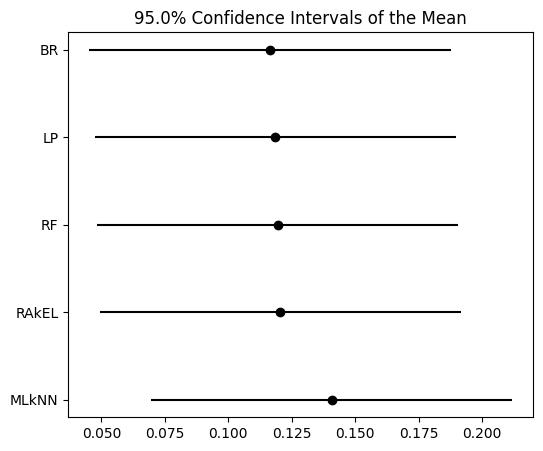


Wilcoxon: BR vs LP
p-valor: 0.3125


In [ ]:
from autorank import autorank, plot_stats
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt

print("\n===== HAMMING =====")

# tabela
df = build_table(all_results, "hamming")
df = df.dropna()
#df = df.drop(columns=["RAkEL"]) # RAkEL não funcionou com o dataset "flags" :/

print(df)

# Friedman + Nemenyi
result = autorank(df, alpha=0.05, order='ascending', verbose=True)

print("\nRanking médio:")
print(result.rankdf)

#plot_stats(result)
#plt.show()

plot_stats(result, allow_insignificant=True)
plt.show()

# Wilcoxon (só com os 2 melhores)
means = df.mean().sort_values(ascending=True)
m1, m2 = means.index[:2]

stat, p = wilcoxon(df[m1], df[m2])

print(f"\nWilcoxon: {m1} vs {m2}")
print("p-valor:", p)

Conclusão: Não foram observadas diferenças estatisticamente significativas entre os modelos p = 0.098653. Embora o modelo Binary Relevance apresente o melhor ranking médio, as diferenças são negligenciáveis. O teste de Wilcoxon também não indicou diferença significativa entre os modelos comparados p = 0.3125.

#### F1-score


===== F1_micro =====
                       BR        LP     RAkEL        RF     MLkNN
dataset                                                          
emotions         0.686909  0.668780  0.675938  0.676610  0.514890
VirusGO          0.864111  0.858351  0.859309  0.858521  0.797980
VirusPseAAC      0.427957  0.389879  0.387690  0.353153  0.469776
GpositiveGO      0.937221  0.939607  0.936698  0.937839  0.938295
GpositivePseAAC  0.642621  0.628353  0.606319  0.629896  0.679966
Fail to reject null hypothesis that data is normal for column BR (p=0.809185>=0.010000)
Fail to reject null hypothesis that data is normal for column LP (p=0.800696>=0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.840606>=0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.744981>=0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.723234>=0.010000)
Using Bartlett's test for homoscedacity of normally distributed data
F

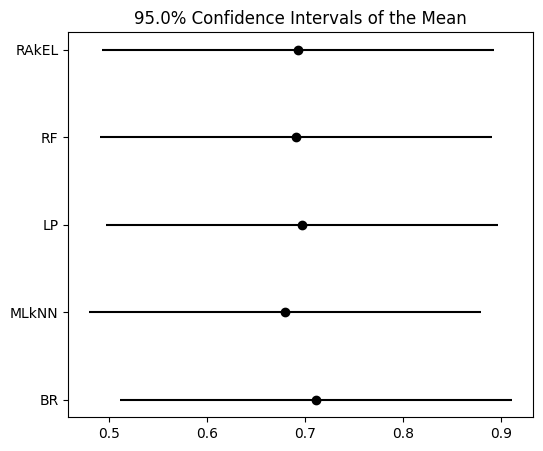


Wilcoxon: MLkNN vs RF
p-valor: 1.0


In [ ]:
from autorank import autorank, plot_stats
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt

print("\n===== F1_micro =====")

# tabela
df = build_table(all_results, "f1_micro")
df = df.dropna()

print(df)

# Friedman + Nemenyi
result = autorank(df, alpha=0.05, order='descending', verbose=True)

print("\nRanking médio:")
print(result.rankdf)

#plot_stats(result)
#plt.show()

plot_stats(result, allow_insignificant=True)
plt.show()

# Wilcoxon (só com os 2 melhores)
means = df.mean().sort_values(ascending=True)
m1, m2 = means.index[:2]

stat, p = wilcoxon(df[m1], df[m2])

print(f"\nWilcoxon: {m1} vs {m2}")
print("p-valor:", p)

Conclusão: Não foram observadas diferenças estatisticamente significativas entre os modelos p = 0.860309. Embora o modelo Binary Relevance apresente o melhor ranking médio, as diferenças são negligenciáveis. O teste de Wilcoxon também não indicou diferença significativa entre os modelos comparados p = 1.0.


===== F1_macro =====
                       BR        LP     RAkEL        RF     MLkNN
dataset                                                          
emotions         0.657074  0.628754  0.643291  0.640969  0.455138
VirusGO          0.816045  0.813881  0.810084  0.803228  0.620898
VirusPseAAC      0.284883  0.283778  0.265989  0.253692  0.347422
GpositiveGO      0.788462  0.791231  0.788933  0.789468  0.840346
GpositivePseAAC  0.444562  0.426170  0.402967  0.428936  0.540844
Fail to reject null hypothesis that data is normal for column BR (p=0.468525>=0.010000)
Fail to reject null hypothesis that data is normal for column LP (p=0.479202>=0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.394830>=0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.423149>=0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.896180>=0.010000)
Using Bartlett's test for homoscedacity of normally distributed data
F

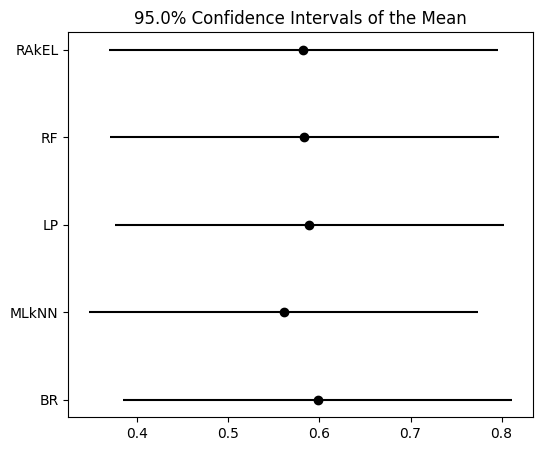


Wilcoxon: MLkNN vs RAkEL
p-valor: 0.8125


In [ ]:
from autorank import autorank, plot_stats
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt

print("\n===== F1_macro =====")

# tabela
df = build_table(all_results, "f1_macro")
df = df.dropna()

print(df)

# Friedman + Nemenyi
result = autorank(df, alpha=0.05, order='descending', verbose=True)

print("\nRanking médio:")
print(result.rankdf)

#plot_stats(result)
#plt.show()

plot_stats(result, allow_insignificant=True)
plt.show()

# Wilcoxon (só com os 2 melhores)
means = df.mean().sort_values(ascending=True)
m1, m2 = means.index[:2]

stat, p = wilcoxon(df[m1], df[m2])

print(f"\nWilcoxon: {m1} vs {m2}")
print("p-valor:", p)

Conclusão: Não foram observadas diferenças estatisticamente significativas entre os modelos p = 0.930537. Embora o modelo Binary Relevance apresente o melhor ranking médio, as diferenças são negligenciáveis. O teste de Wilcoxon também não indicou diferença significativa entre os modelos comparados p = 0.8125.

#### AUPRC

In [ ]:
from autorank import autorank, plot_stats
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt

print("\n===== AUPRC_micro =====")

# tabela
df = build_table(all_results, "auprc_micro")
df = df.dropna()

print(df)

# Friedman + Nemenyi
result = autorank(df, alpha=0.05, order='descending', verbose=True)

print("\nRanking médio:")
print(result.rankdf)

#plot_stats(result)
#plt.show()

plot_stats(result, allow_insignificant=True)
plt.show()

# Wilcoxon (só com os 2 melhores)
means = df.mean().sort_values(ascending=True)
m1, m2 = means.index[:2]

stat, p = wilcoxon(df[m1], df[m2])

print(f"\nWilcoxon: {m1} vs {m2}")
print("p-valor:", p)


===== AUPRC_micro =====
Empty DataFrame
Columns: [BR, LP, RAkEL, RF, MLkNN]
Index: []


ValueError: requires at least five performance estimations (i.e., rows)

Conclusão:

In [ ]:
from autorank import autorank, plot_stats
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt

print("\n===== AUPRC_macro =====")

# tabela
df = build_table(all_results, "auprc_macro")
df = df.dropna()

print(df)

# Friedman + Nemenyi
result = autorank(df, alpha=0.05, order='descending', verbose=True)

print("\nRanking médio:")
print(result.rankdf)

#plot_stats(result)
#plt.show()

plot_stats(result, allow_insignificant=True)
plt.show()

# Wilcoxon (só com os 2 melhores)
means = df.mean().sort_values(ascending=True)
m1, m2 = means.index[:2]

stat, p = wilcoxon(df[m1], df[m2])

print(f"\nWilcoxon: {m1} vs {m2}")
print("p-valor:", p)


===== AUPRC_macro =====
Empty DataFrame
Columns: [BR, LP, RAkEL, RF, MLkNN]
Index: []


ValueError: requires at least five performance estimations (i.e., rows)

Conclusão:

#### AUC

In [ ]:
from autorank import autorank, plot_stats
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt

print("\n===== AUC_micro =====")

# tabela
df = build_table(all_results, "auc_micro")
df = df.dropna()

print(df)

# Friedman + Nemenyi
result = autorank(df, alpha=0.05, order='descending', verbose=True)

print("\nRanking médio:")
print(result.rankdf)

#plot_stats(result)
#plt.show()

plot_stats(result, allow_insignificant=True)
plt.show()

# Wilcoxon (só com os 2 melhores)
means = df.mean().sort_values(ascending=True)
m1, m2 = means.index[:2]

stat, p = wilcoxon(df[m1], df[m2])

print(f"\nWilcoxon: {m1} vs {m2}")
print("p-valor:", p)


===== AUC_micro =====
Empty DataFrame
Columns: [BR, LP, RAkEL, RF, MLkNN]
Index: []


ValueError: requires at least five performance estimations (i.e., rows)

Conclusão:

In [ ]:
from autorank import autorank, plot_stats
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt

print("\n===== AUC_macro =====")

# tabela
df = build_table(all_results, "auc_macro")
df = df.dropna()

print(df)

# Friedman + Nemenyi
result = autorank(df, alpha=0.05, order='descending', verbose=True)

print("\nRanking médio:")
print(result.rankdf)

#plot_stats(result)
#plt.show()

plot_stats(result, allow_insignificant=True)
plt.show()

# Wilcoxon (só com os 2 melhores)
means = df.mean().sort_values(ascending=True)
m1, m2 = means.index[:2]

stat, p = wilcoxon(df[m1], df[m2])

print(f"\nWilcoxon: {m1} vs {m2}")
print("p-valor:", p)

Conclusão: